Plotting of FSI II results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

def plot_results(file_displacement_list, file_forces_list, t_start=None, t_end=None, 
                 labels=None, show_stats=True, enhanced_grid=True, featflow_files=None, 
                 featflow_labels=None, featflow_time_shifts=None, plot_differences=True):
    """
    Read multiple txt files and FeatFlow .point files, plot results vs time with statistics.
    
    Parameters:
    -----------
    file_displacement_list : list of str
        List of displacement files. Each file: # Time u_x(A) u_y(A)
    file_forces_list : list of str
        List of forces files. Each file: # Time F_D F_L Pressure_Diff
    t_start : float or None
        If provided, limits the lower bound of the fixed time window for plots and stats.
    t_end : float or None
        If provided, limits the upper bound of the fixed time window for plots and stats.
    labels : list of str
        Labels for each dataset (default: File 1, File 2, ...)
    show_stats : bool
        Whether to show statistics on plots (default: True)
    enhanced_grid : bool
        Whether to use enhanced grid with minor lines (default: True)
    featflow_files : list of str or str or None
        List of FeatFlow .point files to include in comparison
    featflow_labels : list of str or None
        Labels for FeatFlow datasets (default: FeatFlow 1, FeatFlow 2, ...)
    featflow_time_shifts : float or list of floats or None
        Time shift(s) to apply to FeatFlow data. Can be a single value applied to all 
        or a list matching the length of featflow_files. (default: 0.0)
    plot_differences : bool
        Whether to plot differences between datasets and FeatFlow (default: True)
    
    Returns:
    --------
    stats : dict
        Dictionary containing statistics for each quantity
    """
    
    # Check if inputs are lists, if not convert to lists
    if isinstance(file_displacement_list, str):
        file_displacement_list =[file_displacement_list]
    if isinstance(file_forces_list, str):
        file_forces_list = [file_forces_list]
    
    # Check that lists have same length
    assert len(file_displacement_list) == len(file_forces_list), \
        "Displacement and forces file lists must have same length"
    
    n_files = len(file_displacement_list)
    
    # Default labels if not provided
    if labels is None:
        labels =[f'Dataset {i+1}' for i in range(n_files)]
    
    # Handle FeatFlow files and their time shifts
    if featflow_files is not None:
        if isinstance(featflow_files, str):
            featflow_files =[featflow_files]
        n_featflow = len(featflow_files)
        
        if featflow_labels is None:
            featflow_labels =[f'FeatFlow {i+1}' for i in range(n_featflow)]
            
        if featflow_time_shifts is None:
            featflow_time_shifts = [0.0] * n_featflow
        elif isinstance(featflow_time_shifts, (int, float)):
            featflow_time_shifts =[float(featflow_time_shifts)] * n_featflow
        else:
            assert len(featflow_time_shifts) == n_featflow, \
                "featflow_time_shifts list must have the same length as featflow_files"
    else:
        featflow_files =[]
        featflow_labels = []
        featflow_time_shifts =[]
        n_featflow = 0
    
    total_datasets = n_files + n_featflow
    
    # Colors and styles for different datasets
    colors = plt.cm.tab10(np.linspace(0, 0.9, total_datasets))
    linestyles = ['-', '--', '-.', ':'] * (total_datasets // 4 + 1)
    
    # Initialize statistics dictionary
    all_labels = labels + featflow_labels
    stats = {label: {} for label in all_labels}
    
    # Store data for all files
    all_data =[]
    
    # Read all standard files first
    for idx, (file_disp, file_force, label) in enumerate(zip(
            file_displacement_list, file_forces_list, labels)):
        
        # Read files
        disp = np.loadtxt(file_disp)
        forces = np.loadtxt(file_force)
        
        # Extract columns
        data_dict = {
            't_disp': disp[:, 0],
            'u_x': disp[:, 1],
            'u_y': disp[:, 2],
            't_force': forces[:, 0],
            'F_D': forces[:, 1],
            'F_L': forces[:, 2],
            'P_diff': forces[:, 3],
            'label': label,
            'color': colors[idx],
            'linestyle': linestyles[idx],
            'is_featflow': False
        }
        all_data.append(data_dict)
    
    # Read FeatFlow .point files
    for idx, (file_point, label, t_shift) in enumerate(zip(featflow_files, featflow_labels, featflow_time_shifts)):
        
        # Read FeatFlow .point file
        # FeatFlow format columns (1-indexed as in GnuPlot):
        # Col 1: Time
        # Col 5 + Col 7: Drag (F_D)
        # Col 6 + Col 8: Lift (F_L)
        # Col 11: X-displacement (u_x)
        # Col 12: Y-displacement (u_y)
        
        point_data = read_featflow_point_file(file_point)
        
        color_idx = n_files + idx
        data_dict = {
            't_disp': point_data[:, 0] + t_shift,  # Time shift applied to translate the curve
            'u_x': point_data[:, 10],              # Column 11 (0-indexed: 10)
            'u_y': point_data[:, 11],              # Column 12 (0-indexed: 11)
            't_force': point_data[:, 0] + t_shift, # Time shift applied to translate the curve
            'F_D': point_data[:, 4] + point_data[:, 6],  # Column 5 + Column 7
            'F_L': point_data[:, 5] + point_data[:, 7],  # Column 6 + Column 8
            'P_diff': None,                        # Not available in FeatFlow format
            'label': label,
            'color': colors[color_idx],
            'linestyle': linestyles[color_idx],
            'is_featflow': True
        }
        all_data.append(data_dict)
    
    # Create two sets of plots: full and trimmed (if t_start or t_end is provided)
    plot_sets =[('Full Time Range', None, None)]
    if t_start is not None or t_end is not None:
        time_strs =[]
        if t_start is not None:
            time_strs.append(f'{t_start:.2f}')
        else:
            time_strs.append('0.00')
            
        if t_end is not None:
            time_strs.append(f'{t_end:.2f}')
        else:
            time_strs.append('End')
        
        plot_title_suffix = f"Time Window: [{', '.join(time_strs)}] s"
        plot_sets.append((plot_title_suffix, t_start, t_end))
    
    for plot_title_suffix, t_min, t_max in plot_sets:
        
        # --- Figure 1: Displacements ---
        fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        fig1.suptitle(f'Displacement at Point A - {plot_title_suffix}', 
                     fontsize=14, fontweight='bold')
        
        # --- Figure 2: Forces and Pressure ---
        fig2, (ax3, ax4, ax5) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
        fig2.suptitle(f'Aerodynamic Forces and Pressure - {plot_title_suffix}', 
                     fontsize=14, fontweight='bold')
        
        # Process each dataset
        for data_dict in all_data:
            
            # Extract data
            t_disp = data_dict['t_disp']
            u_x = data_dict['u_x']
            u_y = data_dict['u_y']
            t_force = data_dict['t_force']
            F_D = data_dict['F_D']
            F_L = data_dict['F_L']
            P_diff = data_dict['P_diff']
            label = data_dict['label']
            color = data_dict['color']
            linestyle = data_dict['linestyle']
            
            # Filter data strictly to the fixed window [t_min, t_max]
            if t_min is not None or t_max is not None:
                # Filter displacement data
                mask_disp = np.ones_like(t_disp, dtype=bool)
                if t_min is not None:
                    mask_disp &= (t_disp >= t_min)
                if t_max is not None:
                    mask_disp &= (t_disp <= t_max)
                
                t_disp_plot = t_disp[mask_disp]
                u_x_plot = u_x[mask_disp]
                u_y_plot = u_y[mask_disp]
                
                # Filter force data
                mask_force = np.ones_like(t_force, dtype=bool)
                if t_min is not None:
                    mask_force &= (t_force >= t_min)
                if t_max is not None:
                    mask_force &= (t_force <= t_max)
                
                t_force_plot = t_force[mask_force]
                F_D_plot = F_D[mask_force]
                F_L_plot = F_L[mask_force]
                if P_diff is not None:
                    P_diff_plot = P_diff[mask_force]
                else:
                    P_diff_plot = None
                
                # Calculate statistics exactly for the points visible in the window
                if show_stats and len(t_disp_plot) > 0:
                    stats[label]['u_x'] = {
                        'mean': np.mean(u_x_plot),
                        'min': np.min(u_x_plot),
                        'max': np.max(u_x_plot),
                        'std': np.std(u_x_plot)
                    }
                    stats[label]['u_y'] = {
                        'mean': np.mean(u_y_plot),
                        'min': np.min(u_y_plot),
                        'max': np.max(u_y_plot),
                        'std': np.std(u_y_plot)
                    }
                if show_stats and len(t_force_plot) > 0:
                    stats[label]['F_D'] = {
                        'mean': np.mean(F_D_plot),
                        'min': np.min(F_D_plot),
                        'max': np.max(F_D_plot),
                        'std': np.std(F_D_plot)
                    }
                    stats[label]['F_L'] = {
                        'mean': np.mean(F_L_plot),
                        'min': np.min(F_L_plot),
                        'max': np.max(F_L_plot),
                        'std': np.std(F_L_plot)
                    }
                    if P_diff_plot is not None:
                        stats[label]['P_diff'] = {
                            'mean': np.mean(P_diff_plot),
                            'min': np.min(P_diff_plot),
                            'max': np.max(P_diff_plot),
                            'std': np.std(P_diff_plot)
                        }
            else:
                # Use full data
                t_disp_plot = t_disp
                u_x_plot = u_x
                u_y_plot = u_y
                t_force_plot = t_force
                F_D_plot = F_D
                F_L_plot = F_L
                P_diff_plot = P_diff
            
            # --- Plot displacements ---
            ax1.plot(t_disp_plot, u_x_plot, color=color, linestyle=linestyle, 
                    linewidth=1.5, label=label, alpha=0.8)
            ax2.plot(t_disp_plot, u_y_plot, color=color, linestyle=linestyle, 
                    linewidth=1.5, label=label, alpha=0.8)
            
            # --- Plot forces ---
            ax3.plot(t_force_plot, F_D_plot, color=color, linestyle=linestyle, 
                    linewidth=1.5, label=label, alpha=0.8)
            ax4.plot(t_force_plot, F_L_plot, color=color, linestyle=linestyle, 
                    linewidth=1.5, label=label, alpha=0.8)
            
            # Only plot pressure difference if available (not for FeatFlow)
            if P_diff_plot is not None:
                ax5.plot(t_force_plot, P_diff_plot, color=color, linestyle=linestyle, 
                        linewidth=1.5, label=label, alpha=0.8)
            
            # Add statistics visualization if this is the trimmed plot
            if (t_min is not None or t_max is not None) and show_stats and label in stats:
                # Add mean lines
                if len(t_disp_plot) > 0:
                    ax1.axhline(y=stats[label]['u_x']['mean'], color=color, 
                               linestyle=':', alpha=0.5, linewidth=1.2)
                    ax1.fill_between(t_disp_plot, 
                                    stats[label]['u_x']['min'], 
                                    stats[label]['u_x']['max'],
                                    color=color, alpha=0.1)
                    
                    ax2.axhline(y=stats[label]['u_y']['mean'], color=color, 
                               linestyle=':', alpha=0.5, linewidth=1.2)
                    ax2.fill_between(t_disp_plot, 
                                    stats[label]['u_y']['min'], 
                                    stats[label]['u_y']['max'],
                                    color=color, alpha=0.1)
                
                if len(t_force_plot) > 0:
                    ax3.axhline(y=stats[label]['F_D']['mean'], color=color, 
                               linestyle=':', alpha=0.5, linewidth=1.2)
                    ax3.fill_between(t_force_plot, 
                                    stats[label]['F_D']['min'], 
                                    stats[label]['F_D']['max'],
                                    color=color, alpha=0.1)
                    
                    ax4.axhline(y=stats[label]['F_L']['mean'], color=color, 
                               linestyle=':', alpha=0.5, linewidth=1.2)
                    ax4.fill_between(t_force_plot, 
                                    stats[label]['F_L']['min'], 
                                    stats[label]['F_L']['max'],
                                    color=color, alpha=0.1)
                    
                    if 'P_diff' in stats[label] and P_diff_plot is not None:
                        ax5.axhline(y=stats[label]['P_diff']['mean'], color=color, 
                                   linestyle=':', alpha=0.5, linewidth=1.2)
                        ax5.fill_between(t_force_plot, 
                                        stats[label]['P_diff']['min'], 
                                        stats[label]['P_diff']['max'],
                                        color=color, alpha=0.1)
        
        # Enforce Fixed X-Axis Limits precisely to the provided[t_start, t_end] window
        if t_min is not None or t_max is not None:
            for ax in [ax1, ax2, ax3, ax4, ax5]:
                ax.set_xlim(left=t_min, right=t_max)

        # Configure axes
        ax1.set_ylabel(r'$u_x(A)$ [m]', fontsize=12)
        ax1.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
        ax1.legend(loc='best', fontsize=10)
        
        ax2.set_xlabel('Time [s]', fontsize=12)
        ax2.set_ylabel(r'$u_y(A)$ [m]', fontsize=12)
        ax2.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
        ax2.legend(loc='best', fontsize=10)
        
        ax3.set_ylabel(r'$F_D$ [N]', fontsize=12)
        ax3.legend(loc='best', fontsize=10)
        
        ax4.set_ylabel(r'$F_L$ [N]', fontsize=12)
        ax4.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
        ax4.legend(loc='best', fontsize=10)
        
        ax5.set_xlabel('Time [s]', fontsize=12)
        ax5.set_ylabel(r'$\Delta P$ [Pa]', fontsize=12)
        ax5.legend(loc='best', fontsize=10)
        
        # Configure grid
        if enhanced_grid:
            for ax in [ax1, ax2, ax3, ax4, ax5]:
                ax.grid(True, which='major', alpha=0.4, linestyle='-', 
                       linewidth=0.8, color='gray')
                ax.grid(True, which='minor', alpha=0.15, linestyle=':', 
                       linewidth=0.5, color='lightgray')
                ax.minorticks_on()
                ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
                ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
                ax.xaxis.set_minor_locator(AutoMinorLocator(2))
                ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        else:
            for ax in[ax1, ax2, ax3, ax4, ax5]:
                ax.grid(True, alpha=0.3)
        
        fig1.tight_layout()
        fig2.tight_layout()
    
    # Plot differences if requested and we have both standard and FeatFlow data
    if plot_differences and n_featflow > 0 and n_files > 0:
        plot_difference_figures(all_data, n_files, n_featflow, labels, featflow_labels,
                               t_start, t_end, enhanced_grid)
    
    # Print statistics table if t_start or t_end was provided
    if (t_start is not None or t_end is not None) and show_stats:
        print_statistics_table(stats, t_start, t_end)
    
    plt.show()
    
    return stats


def read_featflow_point_file(filename):
    """
    Read a FeatFlow .point file.
    """
    data_lines =[]
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            # Skip empty lines and comments
            if not line or line.startswith('#') or line.startswith('%'):
                continue
            # Try to parse as numbers
            try:
                values = [float(x) for x in line.split()]
                if len(values) > 0:
                    data_lines.append(values)
            except ValueError:
                continue
    
    return np.array(data_lines)


def plot_difference_figures(all_data, n_files, n_featflow, labels, featflow_labels,
                           t_start, t_end, enhanced_grid):
    """
    Plot difference figures comparing standard datasets with FeatFlow datasets.
    """
    
    # Separate standard and FeatFlow data
    standard_data = all_data[:n_files]
    featflow_data = all_data[n_files:]
    
    # For each combination of standard and FeatFlow data
    for std_data in standard_data:
        for ff_data in featflow_data:
            
            std_label = std_data['label']
            ff_label = ff_data['label']
            
            # Interpolate to common time grid for displacements
            t_common_disp, u_x_diff, u_y_diff = compute_difference(
                std_data['t_disp'], std_data['u_x'], std_data['u_y'],
                ff_data['t_disp'], ff_data['u_x'], ff_data['u_y'],
                t_start, t_end
            )
            
            # Interpolate to common time grid for forces
            t_common_force, F_D_diff, F_L_diff = compute_difference(
                std_data['t_force'], std_data['F_D'], std_data['F_L'],
                ff_data['t_force'], ff_data['F_D'], ff_data['F_L'],
                t_start, t_end
            )
            
            # --- Figure: Displacement Differences ---
            fig_diff1, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
            fig_diff1.suptitle(f'Displacement Difference: {std_label} - {ff_label}', 
                              fontsize=14, fontweight='bold')
            
            ax1.plot(t_common_disp, u_x_diff, 'b-', linewidth=1.5, label=r'$\Delta u_x$')
            ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5, linewidth=1)
            ax1.set_ylabel(r'$\Delta u_x$ [m]', fontsize=12)
            ax1.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
            ax1.legend(loc='best', fontsize=10)
            
            ax2.plot(t_common_disp, u_y_diff, 'r-', linewidth=1.5, label=r'$\Delta u_y$')
            ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5, linewidth=1)
            ax2.set_xlabel('Time [s]', fontsize=12)
            ax2.set_ylabel(r'$\Delta u_y$ [m]', fontsize=12)
            ax2.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
            ax2.legend(loc='best', fontsize=10)
            
            # --- Figure: Force Differences ---
            fig_diff2, (ax3, ax4) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
            fig_diff2.suptitle(f'Force Difference: {std_label} - {ff_label}', 
                              fontsize=14, fontweight='bold')
            
            ax3.plot(t_common_force, F_D_diff, 'g-', linewidth=1.5, label=r'$\Delta F_D$')
            ax3.axhline(y=0, color='k', linestyle='--', alpha=0.5, linewidth=1)
            ax3.set_ylabel(r'$\Delta F_D$ [N]', fontsize=12)
            ax3.legend(loc='best', fontsize=10)
            
            ax4.plot(t_common_force, F_L_diff, 'm-', linewidth=1.5, label=r'$\Delta F_L$')
            ax4.axhline(y=0, color='k', linestyle='--', alpha=0.5, linewidth=1)
            ax4.set_xlabel('Time [s]', fontsize=12)
            ax4.set_ylabel(r'$\Delta F_L$ [N]', fontsize=12)
            ax4.legend(loc='best', fontsize=10)
            
            # Enforce Fixed X-Axis Limits for difference plots
            if t_start is not None or t_end is not None:
                for ax in [ax1, ax2, ax3, ax4]:
                    ax.set_xlim(left=t_start, right=t_end)

            # Add statistics annotations
            add_difference_stats(ax1, u_x_diff, 'u_x')
            add_difference_stats(ax2, u_y_diff, 'u_y')
            add_difference_stats(ax3, F_D_diff, 'F_D')
            add_difference_stats(ax4, F_L_diff, 'F_L')
            
            # Configure grid
            for ax in[ax1, ax2, ax3, ax4]:
                if enhanced_grid:
                    ax.grid(True, which='major', alpha=0.4, linestyle='-', 
                           linewidth=0.8, color='gray')
                    ax.grid(True, which='minor', alpha=0.15, linestyle=':', 
                           linewidth=0.5, color='lightgray')
                    ax.minorticks_on()
                    ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
                    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
                    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
                    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
                else:
                    ax.grid(True, alpha=0.3)
            
            fig_diff1.tight_layout()
            fig_diff2.tight_layout()
            
            # Print difference statistics
            print_difference_statistics(std_label, ff_label, 
                                       t_common_disp, u_x_diff, u_y_diff,
                                       t_common_force, F_D_diff, F_L_diff)


def compute_difference(t1, y1a, y1b, t2, y2a, y2b, t_start=None, t_end=None):
    """
    Compute the difference between two datasets by interpolating to a common time grid.
    """
    # Determine common time range
    t_min = max(t1.min(), t2.min())
    t_max = min(t1.max(), t2.max())
    
    if t_start is not None:
        t_min = max(t_min, t_start)
    if t_end is not None:
        t_max = min(t_max, t_end)
    
    # Use the denser time array within common range
    mask1 = (t1 >= t_min) & (t1 <= t_max)
    mask2 = (t2 >= t_min) & (t2 <= t_max)
    
    n1 = np.sum(mask1)
    n2 = np.sum(mask2)
    
    # Use the time array with more points as the common grid
    if n1 >= n2 and n1 > 0:
        t_common = t1[mask1]
        y1a_interp = y1a[mask1]
        y1b_interp = y1b[mask1]
        y2a_interp = np.interp(t_common, t2, y2a)
        y2b_interp = np.interp(t_common, t2, y2b)
    elif n2 > 0:
        t_common = t2[mask2]
        y1a_interp = np.interp(t_common, t1, y1a)
        y1b_interp = np.interp(t_common, t1, y1b)
        y2a_interp = y2a[mask2]
        y2b_interp = y2b[mask2]
    else:
        return np.array([]), np.array([]), np.array([])
        
    diff_a = y1a_interp - y2a_interp
    diff_b = y1b_interp - y2b_interp
    
    return t_common, diff_a, diff_b


def add_difference_stats(ax, diff_data, qty_name):
    """Add statistics annotation to difference plot."""
    if len(diff_data) == 0:
        return
        
    mean_diff = np.mean(diff_data)
    max_abs_diff = np.max(np.abs(diff_data))
    rms_diff = np.sqrt(np.mean(diff_data**2))
    
    stats_text = f'Mean: {mean_diff:.3e}\nMax |Δ|: {max_abs_diff:.3e}\nRMS: {rms_diff:.3e}'
    
    # Add text box
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)


def print_difference_statistics(std_label, ff_label, 
                                t_disp, u_x_diff, u_y_diff,
                                t_force, F_D_diff, F_L_diff):
    """Print detailed difference statistics."""
    print(f"\n{'='*80}")
    print(f"DIFFERENCE STATISTICS: {std_label} - {ff_label}")
    print(f"{'='*80}")
    print(f"\n{'Quantity':<15} {'Mean Diff':>12} {'Max |Diff|':>12} {'RMS':>12} {'Rel. Max %':>12}")
    print(f"{'-'*63}")
    
    for qty_name, diff_data in[('u_x', u_x_diff), ('u_y', u_y_diff), 
                                ('F_D', F_D_diff), ('F_L', F_L_diff)]:
        if len(diff_data) == 0:
            print(f"{qty_name:<15} {'N/A':>12} {'N/A':>12} {'N/A':>12} {'N/A':>11}")
            continue
            
        mean_diff = np.mean(diff_data)
        max_abs_diff = np.max(np.abs(diff_data))
        rms_diff = np.sqrt(np.mean(diff_data**2))
        
        # Calculate relative difference (as percentage of range)
        data_range = np.max(diff_data) - np.min(diff_data)
        if data_range != 0:
            rel_max = (max_abs_diff / (np.max(np.abs(diff_data - mean_diff)) + 1e-10)) * 100
        else:
            rel_max = 0.0
        
        print(f"{qty_name:<15} {mean_diff:>12.3e} {max_abs_diff:>12.3e} {rms_diff:>12.3e} {rel_max:>11.2f}%")
    
    print(f"{'='*80}\n")


def print_statistics_table(stats, t_start, t_end):
    """Print a formatted table of statistics."""
    print(f"\n{'='*80}")
    time_strs =[]
    if t_start is not None:
        time_strs.append(f'{t_start:.2f}')
    else:
        time_strs.append('0.00')
        
    if t_end is not None:
        time_strs.append(f'{t_end:.2f}')
    else:
        time_strs.append('End')
        
    print(f"STATISTICS FOR TIME WINDOW:[{', '.join(time_strs)}] s")
    print(f"{'='*80}")
    
    for label, data in stats.items():
        print(f"\n{label}:")
        print(f"{'-'*60}")
        print(f"{'Quantity':<15} {'Mean':>12} {'Min':>12} {'Max':>12} {'Range':>12}")
        print(f"{'-'*60}")
        
        for qty in['u_x', 'u_y', 'F_D', 'F_L', 'P_diff']:
            if qty in data and data[qty] is not None:
                mean = data[qty]['mean']
                min_val = data[qty]['min']
                max_val = data[qty]['max']
                range_val = max_val - min_val
                
                # Format based on magnitude
                if abs(mean) < 1e-3 or abs(mean) > 1e3:
                    print(f"{qty:<15} {mean:>12.3e} {min_val:>12.3e} {max_val:>12.3e} {range_val:>12.3e}")
                else:
                    print(f"{qty:<15} {mean:>12.4f} {min_val:>12.4f} {max_val:>12.4f} {range_val:>12.4f}")
    
    print(f"{'='*80}\n")


DIFFERENCE STATISTICS: ref 1 - FeatFlow FSI2

Quantity           Mean Diff   Max |Diff|          RMS   Rel. Max %
---------------------------------------------------------------
u_x               -3.545e-03    7.195e-03    4.065e-03      174.08%
u_y                4.645e-04    1.052e-02    6.717e-03       99.80%
F_D                1.096e+01    5.104e+01    1.814e+01      127.34%
F_L               -9.854e-01    1.041e+02    3.296e+01      100.96%


DIFFERENCE STATISTICS: ref 2 - FeatFlow FSI2

Quantity           Mean Diff   Max |Diff|          RMS   Rel. Max %
---------------------------------------------------------------
u_x               -8.721e-04    4.708e-03    1.632e-03      122.74%
u_y                2.511e-04    1.134e-02    4.420e-03      102.26%
F_D                2.021e+00    2.957e+01    7.597e+00      107.33%
F_L                1.922e-01    6.829e+01    1.629e+01      100.28%


STATISTICS FOR TIME WINDOW:[10.54, 14.00] s

ref 1:
-------------------------------------------

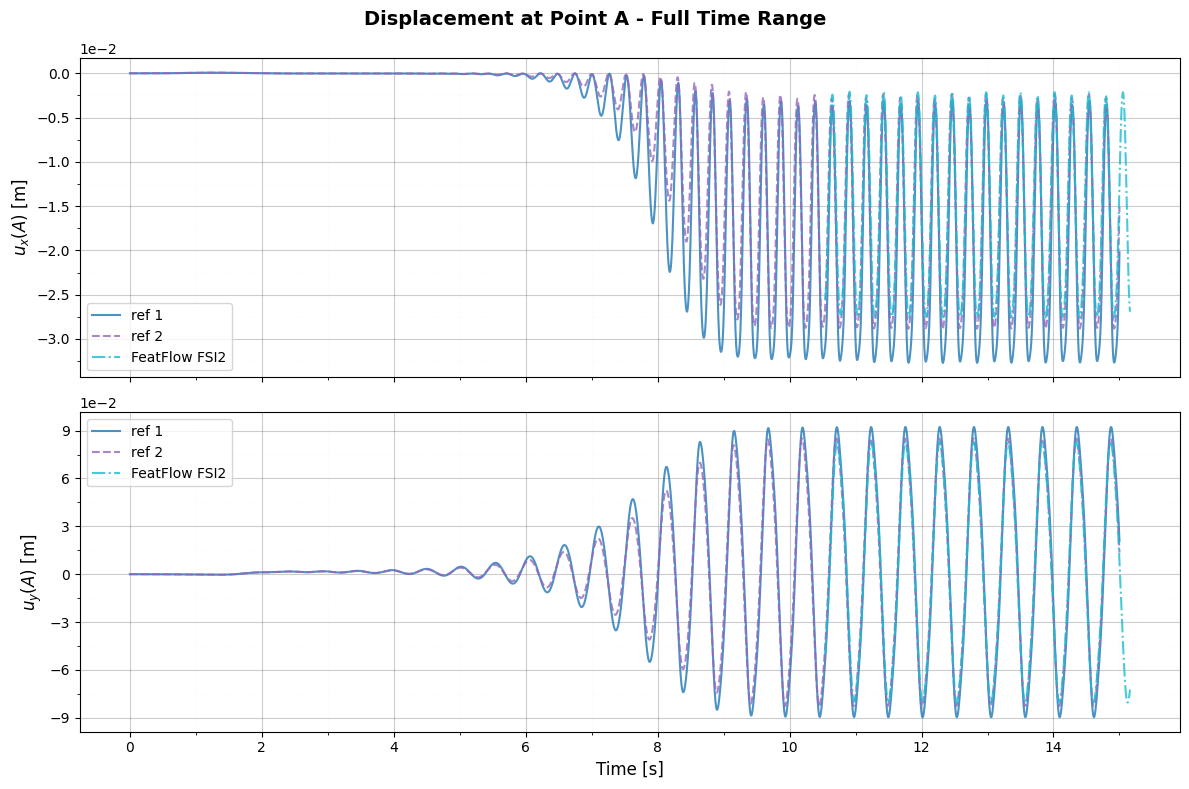

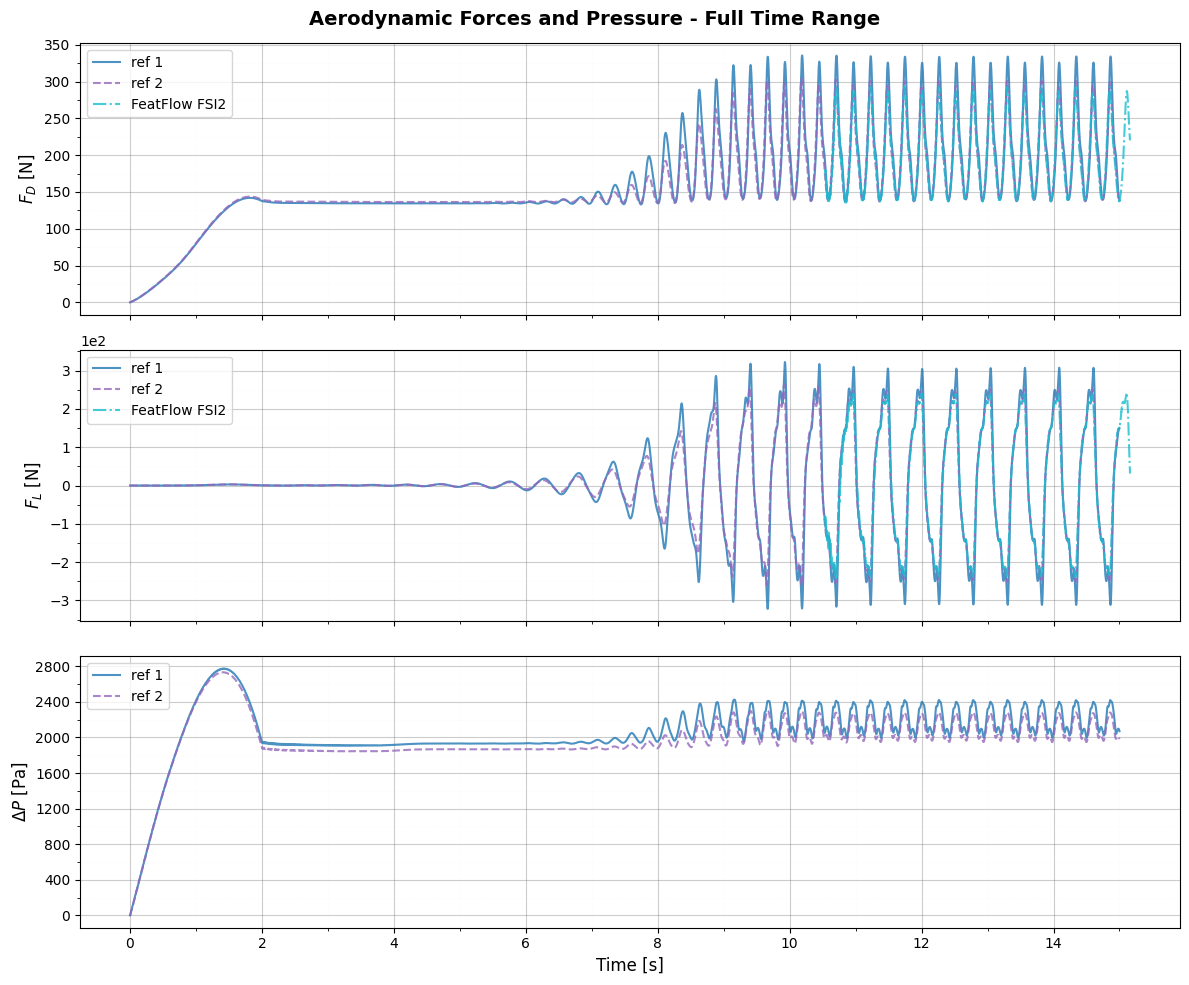

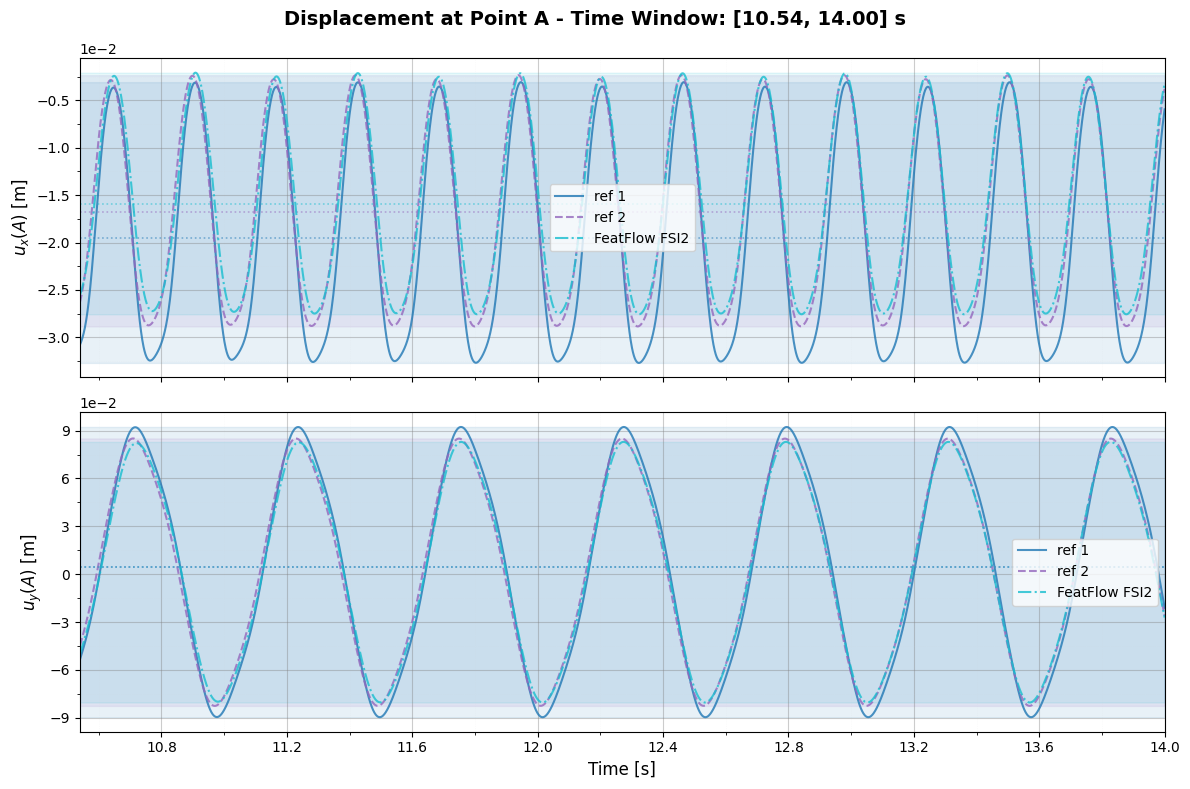

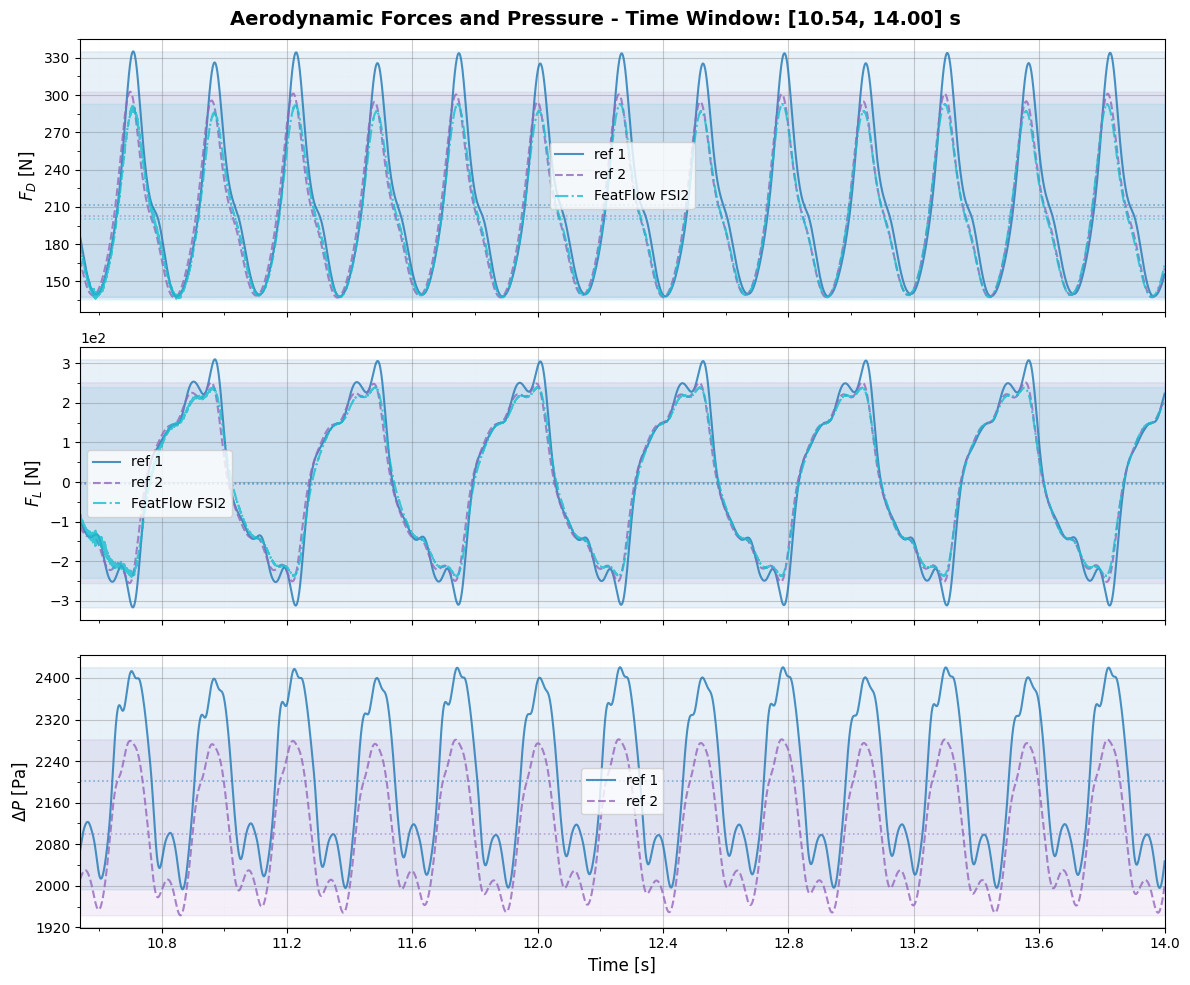

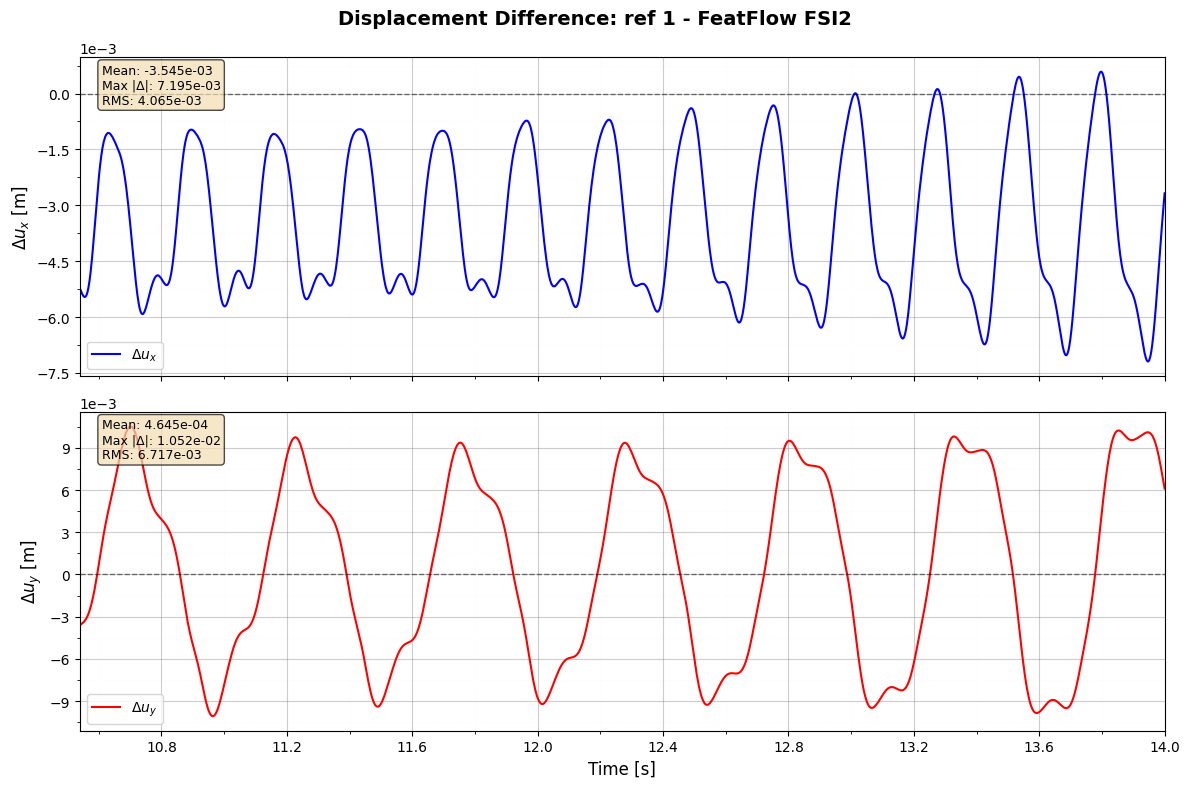

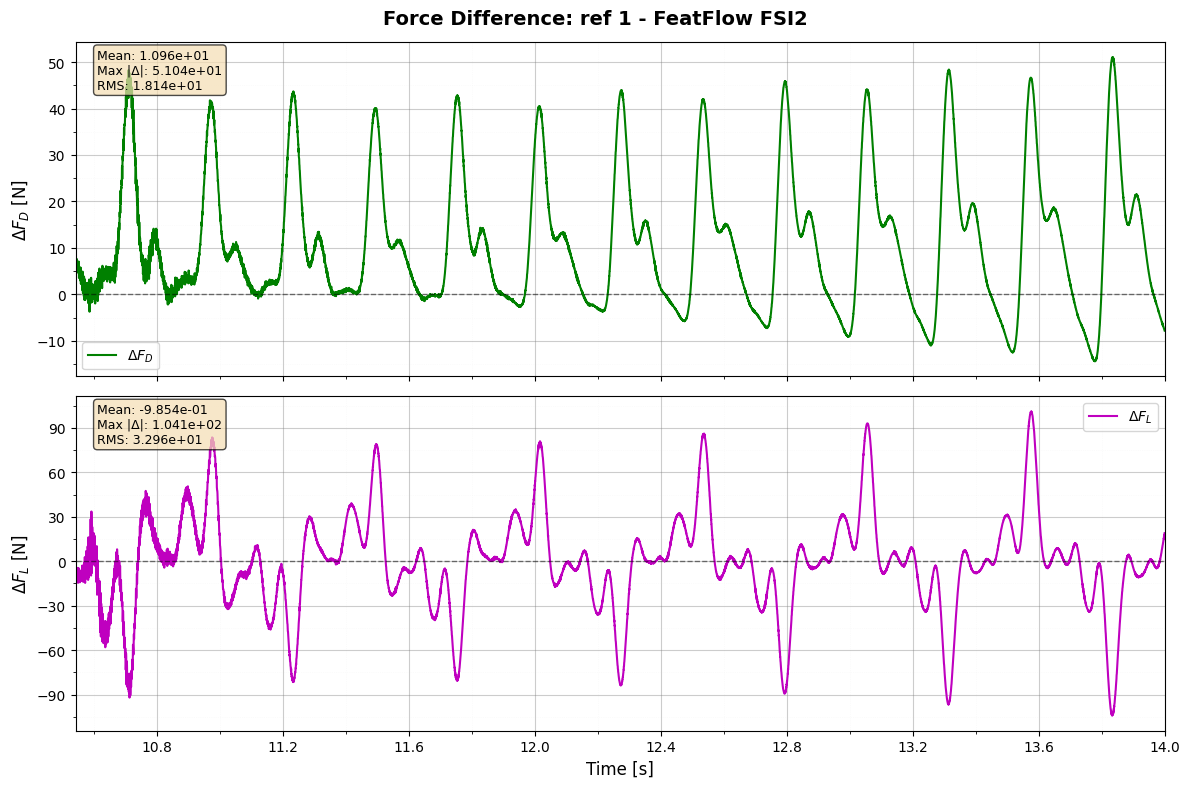

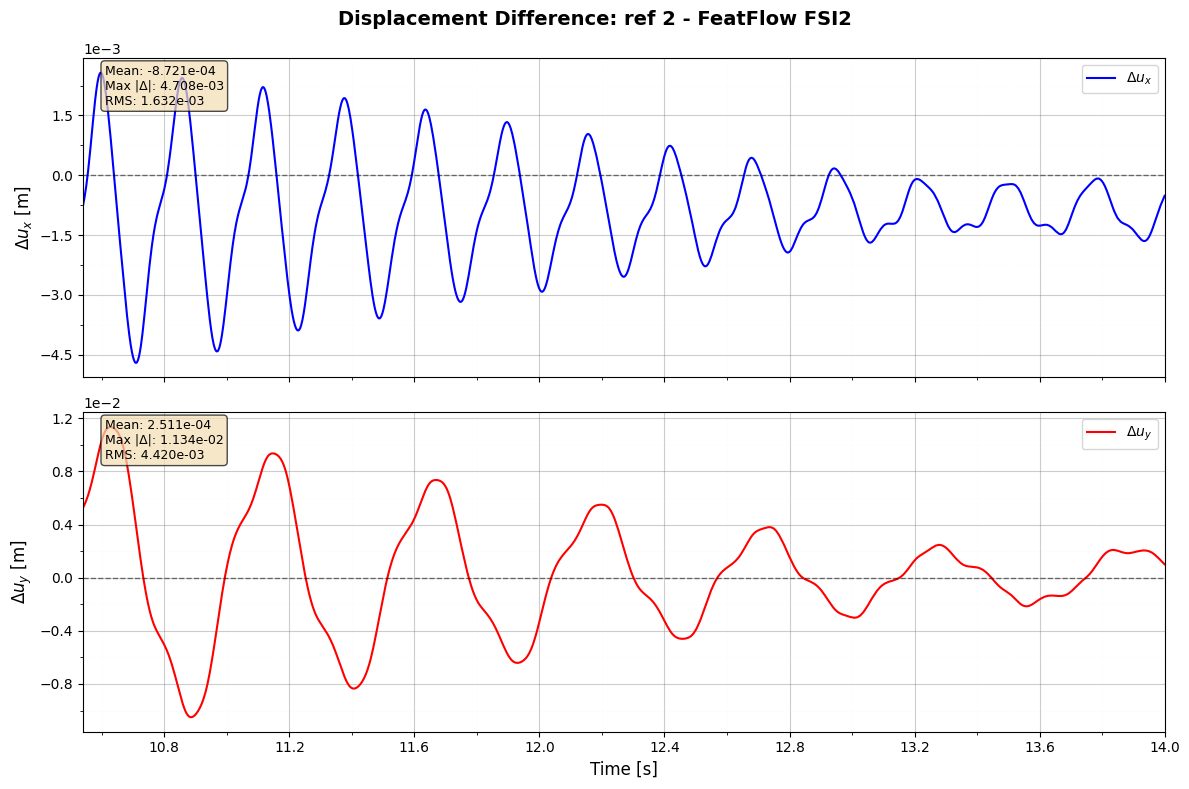

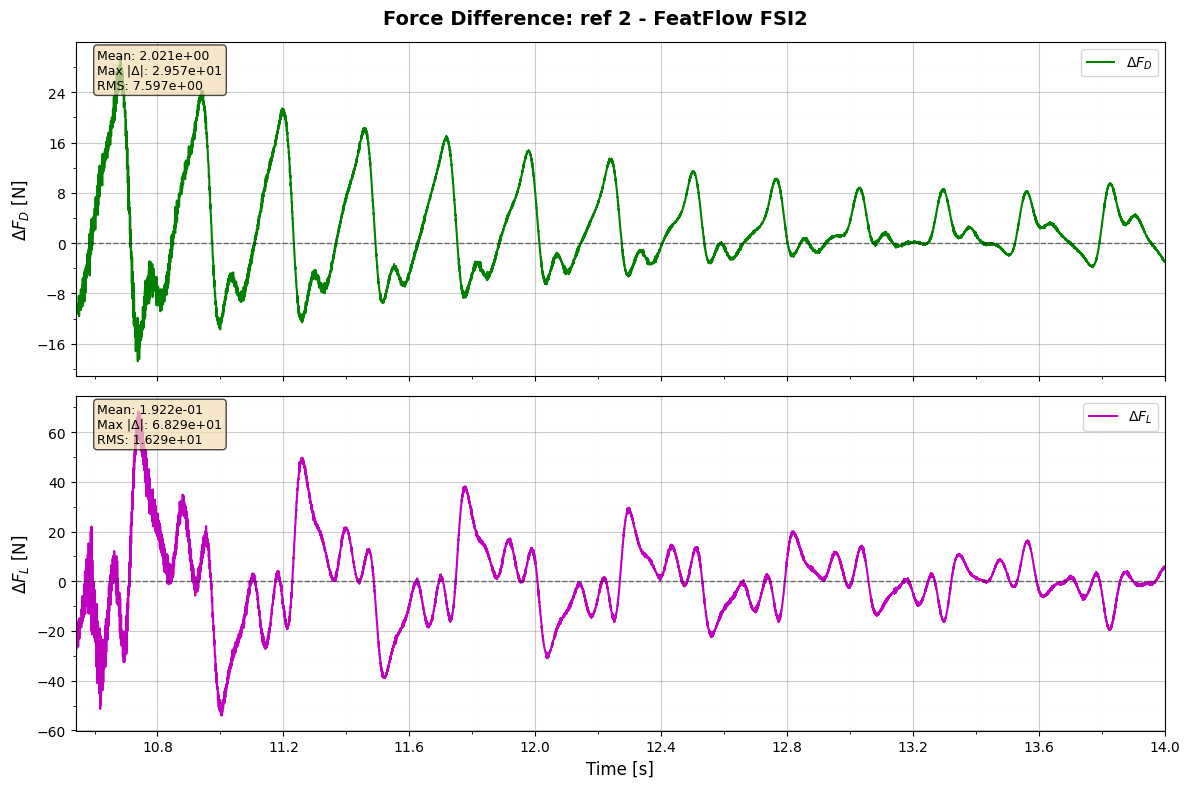

In [ ]:
file_displacement1 = '/root/research_project/FSI/FSI_II_BENCHMARK/FSI_Benchmark_II_Results_biharmonic/displacement_history.txt'  # ← change path here
file_forces1       = '/root/research_project/FSI/FSI_II_BENCHMARK/FSI_Benchmark_II_Results_biharmonic/force_history.txt'        # ← change path here

file_displacement2 = '/root/research_project/FSI/FSI_II_BENCHMARK/FSI_Benchmark_II_Results_biharmonic_mesh_ref/displacement_history.txt'  # ← change path here
file_forces2      = '/root/research_project/FSI/FSI_II_BENCHMARK/FSI_Benchmark_II_Results_biharmonic_mesh_ref/force_history.txt'        # ← change path here

file_displacement3 = '/root/research_project/FSI/FSI_II_BENCHMARK/FSI_Benchmark_II_Results_biharmonic_mesh_ref2/displacement_history.txt'  # ← change path here
file_forces3     = '/root/research_project/FSI/FSI_II_BENCHMARK/FSI_Benchmark_II_Results_biharmonic_mesh_re2f/force_history.txt'        # ← change path here

# Example usage
if __name__ == "__main__":
    # Example with both standard files and FeatFlow files
    
    # Standard files
    disp_files = [file_displacement1, 
                  file_displacement2,
                  file_displacement3]
    force_files = [file_forces1, 
                   file_forces2,
                   file_forces3]
    
    # FeatFlow .point files
    featflow_files = ['/root/research_project/FSI/FSI_II_BENCHMARK/ref_fsi2.point']
    featflow_labels = ['FeatFlow FSI2']
    
    # Call the function
    stats = plot_results(
        file_displacement_list=disp_files,
        file_forces_list=force_files,
        t_start=10.54,
        t_end = 14.0,
        labels=['ref 1', 'ref 2', 'ref 3'],
        featflow_files=featflow_files,
        featflow_labels=featflow_labels,
        plot_differences=True,
        show_stats=True,
        enhanced_grid=True,
        featflow_time_shifts=0.54
    )